# Employee Attrition Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(42)

---
## Part 1: Data Exploration

### 1. Load the dataset and review its structure

In [2]:
df = pd.read_csv("Employee.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (4653, 9)


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2013,New Delhi,2,32,Male,No,4,0
1,Bachelors,2016,New Delhi,3,30,Female,No,4,0
2,Masters,2018,Bangalore,2,36,Male,No,1,0
3,Bachelors,2018,Pune,3,39,Female,No,5,1
4,Bachelors,2013,Bangalore,3,25,Female,No,3,0


In [3]:
# Structure, column data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Education                  4653 non-null   str  
 1   JoiningYear                4653 non-null   int64
 2   City                       4653 non-null   str  
 3   PaymentTier                4653 non-null   int64
 4   Age                        4653 non-null   int64
 5   Gender                     4653 non-null   str  
 6   EverBenched                4653 non-null   str  
 7   ExperienceInCurrentDomain  4653 non-null   int64
 8   LeaveOrNot                 4653 non-null   int64
dtypes: int64(5), str(4)
memory usage: 327.3 KB


### 2. Identify the categorical and numerical features

In [4]:
categorical_features = ["Education", "City", "Gender", "EverBenched"]
numerical_features   = ["JoiningYear", "PaymentTier", "Age", "ExperienceInCurrentDomain"]
target = "LeaveOrNot"

print("Categorical features:", categorical_features)
print("Numerical features  :", numerical_features)
print("Target              :", target)

Categorical features: ['Education', 'City', 'Gender', 'EverBenched']
Numerical features  : ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']
Target              : LeaveOrNot


### 3. Check for missing values

In [5]:
missing = df.isnull().sum()
print(missing)
print("\nTotal missing values:", missing.sum())

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

Total missing values: 0


### 4. Summary statistics for numerical features

In [6]:
df[["Age", "PaymentTier", "ExperienceInCurrentDomain"]].describe()

,Age,PaymentTier,ExperienceInCurrentDomain
count,4653.000000,4653.000000,4653.000000
mean,31.611433,2.702987,3.495809
std,5.830352,0.560894,2.296263
min,22.000000,1.000000,0.000000
25%,26.000000,3.000000,1.000000
50%,32.000000,3.000000,4.000000
75%,37.000000,3.000000,6.000000
max,41.000000,3.000000,7.000000


### 5. Distribution of categorical features

In [7]:
for col in categorical_features:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Education ---
Education
Bachelors    3602
Masters       874
PHD           177
Name: count, dtype: int64

--- City ---
City
Bangalore    2224
Pune         1328
New Delhi    1101
Name: count, dtype: int64

--- Gender ---
Gender
Male      2800
Female    1853
Name: count, dtype: int64

--- EverBenched ---
EverBenched
No     4183
Yes     470
Name: count, dtype: int64



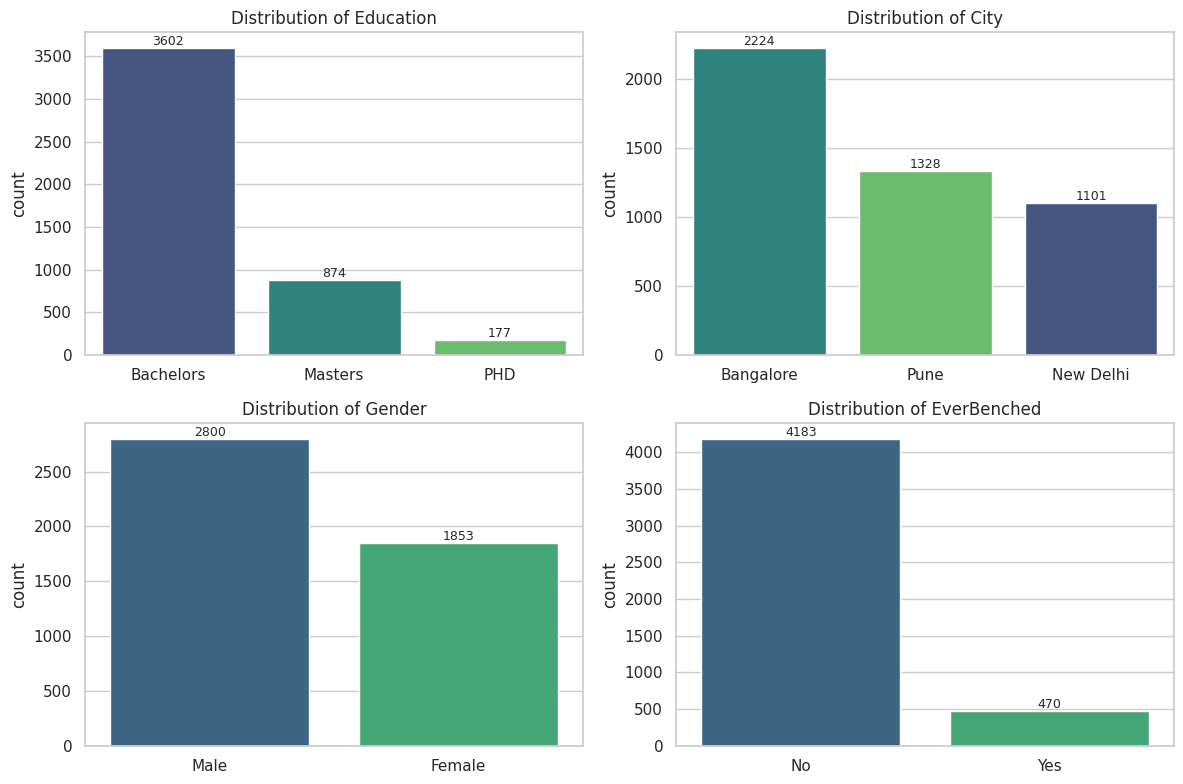

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, hue=col,
                  palette="viridis", legend=False)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("")
    for p in ax.patches:
        ax.annotate(int(p.get_height()),
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 6. Distribution of the target variable `LeaveOrNot`

LeaveOrNot
0    3234
1    1419
Name: count, dtype: int64

Class balance (%):
LeaveOrNot
0    69.5
1    30.5
Name: proportion, dtype: float64


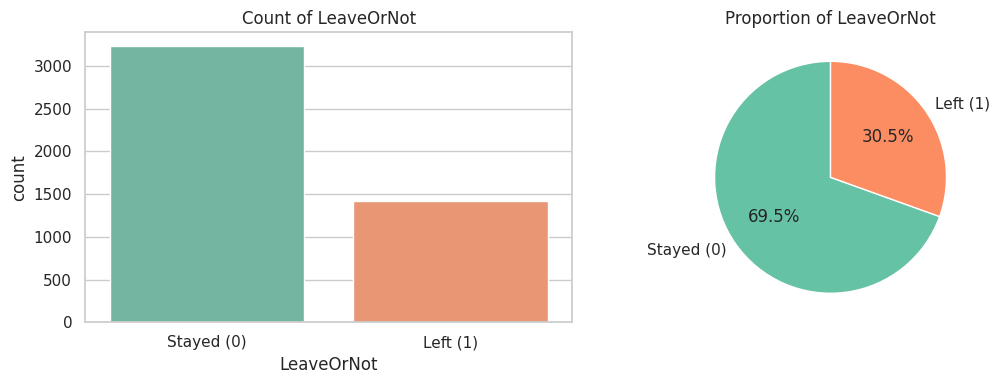

In [9]:
counts = df[target].value_counts().sort_index()
pct = df[target].value_counts(normalize=True).sort_index() * 100
print(counts)
print("\nClass balance (%):")
print(pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x=target, ax=ax[0], hue=target, palette="Set2", legend=False)
ax[0].set_title("Count of LeaveOrNot")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Stayed (0)", "Left (1)"])
ax[1].pie(counts, labels=["Stayed (0)", "Left (1)"], autopct="%1.1f%%",
          colors=sns.color_palette("Set2"), startangle=90)
ax[1].set_title("Proportion of LeaveOrNot")
plt.tight_layout()
plt.show()

**Observation:** The classes are imbalanced — most employees stayed, while a smaller
share left. We keep this in mind during evaluation and use **stratified** splitting so the
train and test sets keep the same class proportions.

---
## Part 2: Data Preprocessing

### 1. Encode the categorical features

We encode each categorical feature *appropriately* for its type:

- **`Education`** is ordinal (Bachelors < Masters < PHD) → ordinal map.
- **`Gender`** and **`EverBenched`** are binary → label encoding (0/1).
- **`City`** is nominal (no inherent order) → one-hot encoding.

In [10]:
df_enc = df.copy()

# Ordinal encoding for Education
education_order = {"Bachelors": 0, "Masters": 1, "PHD": 2}
df_enc["Education"] = df_enc["Education"].map(education_order)

# Binary label encoding
df_enc["Gender"]      = df_enc["Gender"].map({"Male": 0, "Female": 1})
df_enc["EverBenched"] = df_enc["EverBenched"].map({"No": 0, "Yes": 1})

# One-hot encoding for the nominal City feature
df_enc = pd.get_dummies(df_enc, columns=["City"], prefix="City")
city_cols = [c for c in df_enc.columns if c.startswith("City_")]
df_enc[city_cols] = df_enc[city_cols].astype(int)

df_enc.head()

,Education,JoiningYear,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,City_Bangalore,City_New Delhi,City_Pune
0,0,2013,2,32,0,0,4,0,0,1,0
1,0,2016,3,30,1,0,4,0,0,1,0
2,1,2018,2,36,0,0,1,0,1,0,0
3,0,2018,3,39,1,0,5,1,0,0,1
4,0,2013,3,25,1,0,3,0,1,0,0


### 2. Handle scaling of numerical features

Tree-based models (Decision Tree, Random Forest) are **scale-invariant** — they split on
thresholds, so scaling is *not required* for them, and we keep the original values so the
tree splits stay human-readable.

Logistic Regression, however, is distance/gradient based and **benefits from scaling**, so we
prepare a separate **standardized** copy of the features for that model.

In [11]:
feature_cols = [c for c in df_enc.columns if c != target]
X = df_enc[feature_cols]      # unscaled  -> used by tree models
y = df_enc[target]

num_to_scale = ["Age", "ExperienceInCurrentDomain", "JoiningYear", "PaymentTier"]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_to_scale] = scaler.fit_transform(X[num_to_scale])

print("Feature columns:", feature_cols)
X_scaled[num_to_scale].describe().round(3)

Feature columns: ['Education', 'JoiningYear', 'PaymentTier', 'Age', 'Gender', 'EverBenched', 'ExperienceInCurrentDomain', 'City_Bangalore', 'City_New Delhi', 'City_Pune']


,Age,ExperienceInCurrentDomain,JoiningYear,PaymentTier
count,4653.000,4653.000,4653.000,4653.000
mean,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-1.649,-1.523,-1.655,-3.037
25%,-0.963,-1.087,-1.187,0.530
50%,0.067,0.220,0.220,0.530
75%,0.924,1.091,0.688,0.530
max,1.610,1.526,1.157,0.530


### 3. Split into training and testing sets (80% / 20%)

In [12]:
# Same split indices for scaled and unscaled versions (stratified on the target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

Xs_train, Xs_test, _, _ = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)

print("Training set:", X_train.shape, " Testing set:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))

Training set: (3722, 10)  Testing set: (931, 10)
Train class balance:
 LeaveOrNot
0    0.695
1    0.305
Name: proportion, dtype: float64


---
## Part 3: Model Building

### 1. Decision Tree Classifier
We grow a standard (unpruned) decision tree. We also compare its **training** and **testing**
accuracy — a large gap is the classic sign that a single tree **over-fits** the training data.

In [13]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
print(f"Decision Tree training accuracy: {dt_train_acc:.4f}")
print(f"Decision Tree test accuracy    : {dt_acc:.4f}")
print("-> The large train/test gap shows the single tree is over-fitting.")

Decision Tree training accuracy: 0.9618
Decision Tree test accuracy    : 0.5983
-> The large train/test gap shows the single tree is over-fitting.


### 2. Random Forest Classifier
A Random Forest averages many de-correlated decision trees, which usually reduces over-fitting
and improves accuracy over a single tree.

In [16]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest test accuracy: {rf_acc:.4f}")

Random Forest test accuracy: 0.6584


### Optional: Logistic Regression (for comparison)

In [17]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(Xs_train, y_train)          # uses the scaled features

lr_pred = logreg.predict(Xs_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression test accuracy: {lr_acc:.4f}")

Logistic Regression test accuracy: 0.6982


---
## Part 4: Model Evaluation

### 1 & 2. Predictions on the test set and accuracy comparison

In [18]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression"],
    "Test Accuracy": [dt_acc, rf_acc, lr_acc]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results["Test Accuracy"] = results["Test Accuracy"].round(4)
results

,Model,Test Accuracy
0,Logistic Regression,0.6982
1,Random Forest,0.6584
2,Decision Tree,0.5983


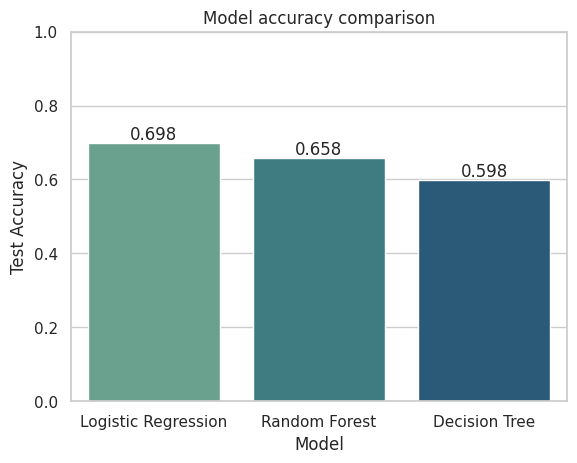

In [19]:
ax = sns.barplot(data=results, x="Model", y="Test Accuracy",
                 hue="Model", palette="crest", legend=False)
ax.set_ylim(0, 1)
ax.set_title("Model accuracy comparison")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

#### Detailed look at the best tree model (confusion matrix + report)

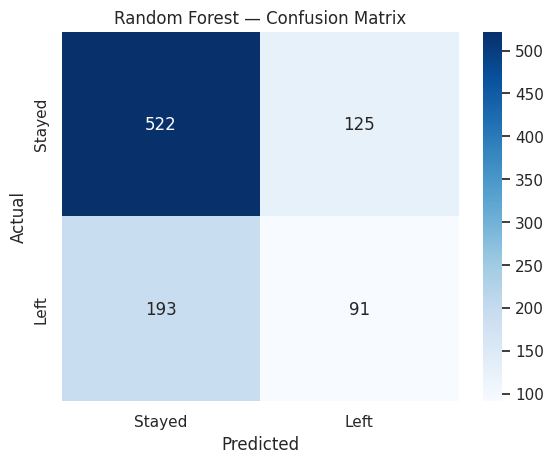

              precision    recall  f1-score   support

      Stayed       0.73      0.81      0.77       647
        Left       0.42      0.32      0.36       284

    accuracy                           0.66       931
   macro avg       0.58      0.56      0.57       931
weighted avg       0.64      0.66      0.64       931



In [20]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Random Forest — Confusion Matrix")
plt.show()

print(classification_report(y_test, rf_pred, target_names=["Stayed", "Left"]))

---
## Part 5: Analysis Questions

### 1. Which features are most important in predicting employee attrition?

Age                          0.3942
ExperienceInCurrentDomain    0.1992
JoiningYear                  0.1651
PaymentTier                  0.0603
Education                    0.0449
Gender                       0.0422
EverBenched                  0.0292
City_Bangalore               0.0229
City_Pune                    0.0214
City_New Delhi               0.0205
dtype: float64


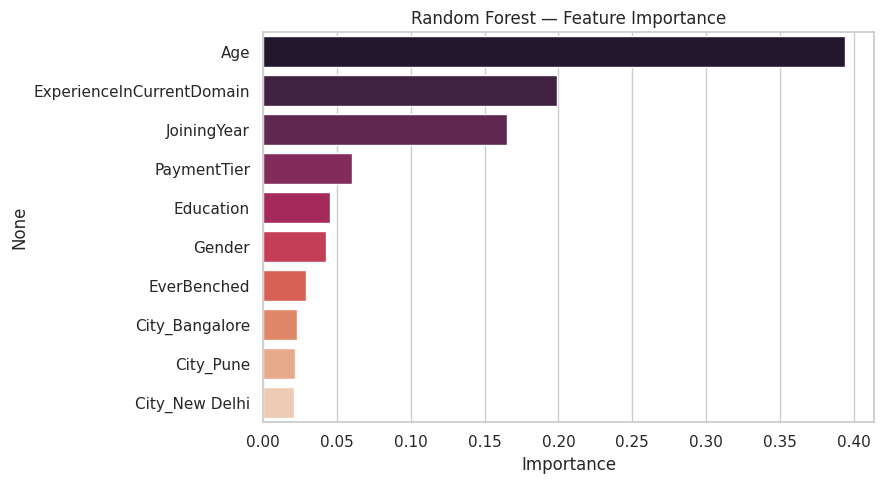

In [21]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print(importances.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index, palette="rocket", legend=False)
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Answer.** The bar chart ranks the features by how much each reduces impurity across the
forest. In this run the strongest predictors are **Age**, **Experience in Current Domain**, and
**Joining Year**, followed by **Payment Tier**; **Education**, **Gender**, the **ever-benched**
flag, and the one-hot **city** columns contribute the least. One caveat: impurity-based
importance is biased toward features with many distinct values (like Age), so it is best read as
a guide rather than an exact ranking. The order can also shift slightly with the random seed or
when you load the official data — read the printed values above for your exact result.

### 2. How do Age and ExperienceInCurrentDomain affect the likelihood of leaving?

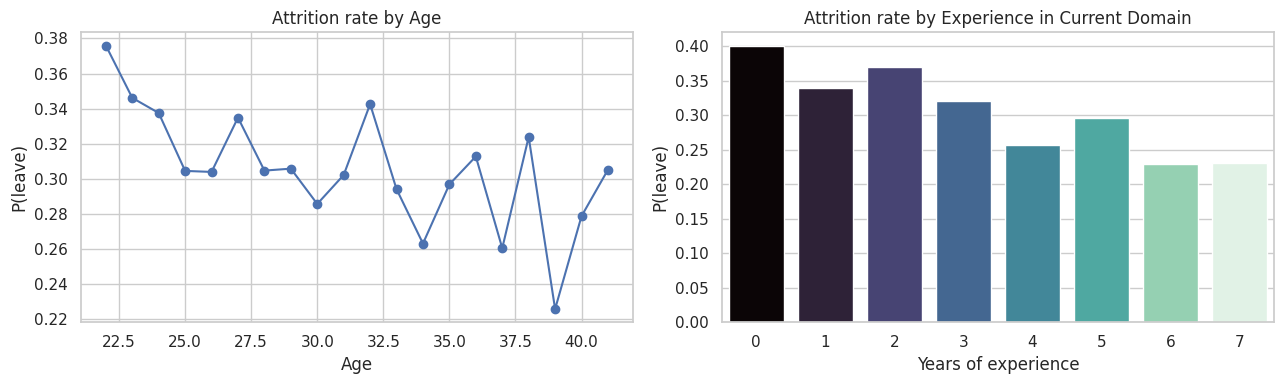

Correlation with LeaveOrNot:
Age                         -0.046
ExperienceInCurrentDomain   -0.119
LeaveOrNot                   1.000
Name: LeaveOrNot, dtype: float64


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

age_rate = df.groupby("Age")["LeaveOrNot"].mean()
ax[0].plot(age_rate.index, age_rate.values, marker="o")
ax[0].set_title("Attrition rate by Age")
ax[0].set_xlabel("Age"); ax[0].set_ylabel("P(leave)")

exp_rate = df.groupby("ExperienceInCurrentDomain")["LeaveOrNot"].mean()
sns.barplot(x=exp_rate.index, y=exp_rate.values, ax=ax[1],
            hue=exp_rate.index, palette="mako", legend=False)
ax[1].set_title("Attrition rate by Experience in Current Domain")
ax[1].set_xlabel("Years of experience"); ax[1].set_ylabel("P(leave)")

plt.tight_layout()
plt.show()

print("Correlation with LeaveOrNot:")
print(df[["Age", "ExperienceInCurrentDomain", "LeaveOrNot"]].corr()["LeaveOrNot"].round(3))

**Answer.** 

Both factors have a slight impact on attrition:
Age: Younger employees are more likely to leave, while older employees generally tend to stay longer.
Experience in Current Domain: Employees with less experience leave more often, whereas those with more experience are usually more likely to remain with the company.However, neither factor alone strongly predicts attrition, so the model uses them together with other features for better predictions.

### 3. Decision Tree vs Random Forest , which performs better and why?

In [23]:
print(f"Decision Tree accuracy : {dt_acc:.4f}")
print(f"Random Forest accuracy : {rf_acc:.4f}")
print(f"Difference             : {rf_acc - dt_acc:+.4f}")

Decision Tree accuracy : 0.5983
Random Forest accuracy : 0.6584
Difference             : +0.0602


**Answer.** The **Random Forest** performs better (higher test accuracy). A single Decision
Tree learns one set of splits and is prone to **over-fitting** — it captures noise specific to
the training data. A Random Forest trains many trees on bootstrapped samples and random feature
subsets, then averages their votes. This **reduces variance** and produces a more stable, more
accurate model that generalizes better to unseen employees. The trade-off is interpretability:
the single tree is easy to read and explain, while the forest is a "black box" we inspect through
feature-importance scores.

### 4. HR strategies based on the analysis

**Answer — recommendations for HR.** 
1. Target early-tenure and younger employees with structured onboarding and mentorship.
2. Review the mid payment tier and act on the gender gap.
3. Run a simple risk model and check in proactively.